In [1]:
%load_ext autoreload
%autoreload 2

# Demo Notebook for CPSY 1950 Project

### Basic Functionalities

This notebook provides a walkthrough of how to access the models hosted on our LiteLLM API. It also introduces how to design and run cognitive psychology–based experiments with these frontier models, inspired by the approach used in Centaur[1].

First, let us see what models are available to use on the API

In [8]:
from openai import OpenAI
from helpers import extract_logprob_table

from tqdm import tqdm

In [14]:
from dotenv import load_dotenv
import os

load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url="https://litellm.ccv.brown.edu"
)

In [15]:
models = client.models.list()

for m in models.data:
    print(m.id)

gpt-5.2
gpt-5.4
Mistral-Large-3
Llama-3.3-70B-Instruct
gemini-2.5-pro
gemini-3-flash-preview
claude-sonnet-4-5
gpt-oss


Below is an example of how to send a prompt to one of these models and retrieve a response. To reduce token usage, we disable the reasoning mode of the model and we explicitly instruct the model to respond with a single word.

In [14]:
example_prompt = 'this is a request, just say hello'

In [23]:
response = client.chat.completions.create(
    model="gpt-5.2", 
    messages=[
        {"role": "user", "content": example_prompt}
    ],
    top_logprobs=5,
    logprobs=True,
    reasoning_effort=None
)


Below demonstrates how to access the response of the model

In [24]:
model_response = response.choices[0].message.content
model_response

'hello'

Notice that we also included the **logprobs** and **top_logprobs** parameters. These are used to expose token-level probability information from the model’s output, which is useful for analyzing uncertainty and model behavior.

- **logprobs**: When set to `True`, the API returns the log probabilities of each generated token. This shows how confident the model was in selecting each token in the output sequence.

- **top_logprobs**: Specifies how many of the most likely alternative tokens to return at each position. For example, `top_logprobs=5` returns the five highest-probability alternative tokens the model considered at each step, along with their log probabilities.

Note that with the OpenAI API the maximum value we can set **top_logprobs** to is 5.

In [25]:
extract_logprob_table(response)

,rank,token,logprob,probability
0,1,hello,-0.000335,9.996646e-01
1,2,Hello,-8.000336,3.353500e-04
2,3,hello,-19.250336,4.361998e-09
3,4,hell,-21.250336,5.903322e-10
4,5,HEL,-22.000336,2.788532e-10


### The OpenAI API `response` object

There are two primary pieces of information we wish to extract from the `response` object returned by the OpenAI API: the token generated by the model, and the probabilities associated with alternative tokens the model could have produced.

This information is accessible via:

`response.choices[0].logprobs.content[0].top_logprobs`

In [79]:
logprobs = response.choices[0].logprobs.content[0].top_logprobs
logprobs

[TopLogprob(token='hello', bytes=[104, 101, 108, 108, 111], logprob=-0.00033546582562848926),
 TopLogprob(token='Hello', bytes=[72, 101, 108, 108, 111], logprob=-8.000335693359375),
 TopLogprob(token=' hello', bytes=[32, 104, 101, 108, 108, 111], logprob=-19.250335693359375),
 TopLogprob(token='hell', bytes=[104, 101, 108, 108], logprob=-21.250335693359375),
 TopLogprob(token='HEL', bytes=[72, 69, 76], logprob=-22.000335693359375)]

Each entry of `logprobs` is a `TopLogProb` object. You can see that for each `logprobs[i]` the token and associated log probability can be accessed via `logprobs[i].token` and `logprobs[i].logprob`

In [82]:
for logprob in logprobs:

    token = logprob.token
    logprob = logprob.logprob

    print(f'The log probability of \"{token}\" is {logprob}')

The log probability of "hello" is -0.00033546582562848926
The log probability of "Hello" is -8.000335693359375
The log probability of " hello" is -19.250335693359375
The log probability of "hell" is -21.250335693359375
The log probability of "HEL" is -22.000335693359375


# Two Example Experiments

### 1) Model Alignment with Human Decisions on the Two Step Task

The two step task is a classic paradigm in decision neuroscience designed to distinguish between two learning strategies: model free learning (habit-based repetition of rewarded actions) and model based learning (planning using an internal model of the task's transition structure).

On each trial, participants make two sequential choices under uncertainty, with reward probabilities that drift slowly over time, meaning their behavior must be continuously adapted and participants cannot settle on a single strategy. 

We use a cover story version of the task, where the abstract structure is wrapped in a fantasy narrative (magic carpets, genies, mountains). The cover story preserves the underlying computational structure while disguising its surface features, this tests whether a model has learned something general about human decision making rather than pattern matching on familiar task descriptions. 

Our metric, only a rough proxy for alignment to human decision making, is negative log likelihood (NLL), i.e how surprised the model is by the human's actual choice at each trial. Lower NLL, as a rough proxy, means better alignment with human behavior.

In [2]:
from datasets import load_dataset

In [4]:
model = 'gpt-5.2'

In [5]:
dataset = load_dataset(
    'json',
    data_files="feher2023rethinking/prompts.jsonl"
)

The below text is transcribed text of one human going through the two step task experiment. It is directly from[2] and was also directly used in the Centaur paper. We will be seeing how aligned gpt-5.2 is with the decisions made by this participant.

In [6]:
full_transcribed_text = dataset['train']['text'][0]

Below is the cover story used during this experiment. 

In [440]:
initial_prompt = """
You are playing the role of a musician living in a fantasy land.

You play the flute for gold coins to an audience of genies, who live inside magic lamps on Pink Mountain and Blue Mountain.

- Pink Mountain has genies C and D.
- Blue Mountain has genies X and F.
- Each genie lives in a lamp with the corresponding letter.

When you arrive on a mountain, you can pick up a lamp and rub it.
If the genie is in the mood for music, he will come out, listen to a song, and give you a gold coin.

Each genie’s interest in music changes over time.

To travel, you choose one of two magic carpets from a magician:
- Magic carpet N usually flies to Pink Mountain.
- Magic carpet J usually flies to Blue Mountain.

However, strong winds can sometimes make landing on a mountain too dangerous.
In that case, the carpet will land on the other mountain instead.

You can take a magic carpet or pick up a lamp and rub it by pressing the corresponding key.
"""

In [426]:
import re

def extract_steps(text):
    pattern = r"<<(.*?)>>"
    matches = list(re.finditer(pattern, text))
    steps = []
    prev_end = 0
    for m in matches:
        start, end = m.span()
        decision = m.group(1).strip()
        prefix = text[prev_end:start]
        if decision.lower() == "nan":
            prev_end = end
            continue
        steps.append({
            "prefix": prefix,
            "decision": decision
        })
        prev_end = end
    return steps

In the original experiment transcripts, human decisions were marked with the format <<`DECISION`>>. At each decision point, we construct a prompt consisting of the initial cover story followed by the full trial by trial history of the participant's choices and outcomes up to that point. We then query the model and extract the log probability it assigns to the token corresponding to the human's actual choice, giving us the NLL for that trial. The context is then updated with the human's real decision before moving to the next trial.

One practical consideration: since we are using a chat completion API rather than direct access to model internals, we must explicitly instruct the model to respond with a single token that is valid within the cover story context. This is a key limitation compared to the original Centaur evaluation, where log probabilities could be extracted from a full forward pass over the entire transcript, instead we are iteratively updating the context of the model based on previous trials. 

In [412]:
model_context = ""
model_context += initial_prompt

steps = extract_steps(full_transcribed_text)

responses_logprobs = []
human_decisions = []

n_trials = 50

for step in tqdm(steps[:n_trials]):

    human_decision = step['decision']
    prefix = step['prefix']

    model_prompt = model_context + prefix  + "<<" + "(Respond with only a single upper case character that makes sense for the described experiment)"
    model_context += prefix + f"<<{human_decision}>>"

    response = client.chat.completions.create(
        model=model, 
        messages=[
            {"role": "user", "content": model_prompt}
        ],
        top_logprobs=5,
        logprobs=True,
        reasoning_effort=None
    )

    logprobs = response.choices[0].logprobs.content[0].top_logprobs
    human_decisions.append(human_decision)
    responses_logprobs.append(logprobs)
    

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:37<00:00,  1.32it/s]


The figures below visualize the model's alignment with human decisions across 50 trials. The left panel shows the NLL of the human's actual choice at each trial, colored by decision stage, blue for stage 1 (carpet choice) and orange for stage 2 (lamp choice), with a 10 trial rolling average overlaid. Lower values indicate the model found the human's choice more predictable given their prior history. The right panel shows top-1 accuracy by stage: the proportion of trials where the model's single most probable token matched the human's actual decision. Together these two panels capture both a graded measure of alignment (NLL) and a more interpretable binary measure (top-1 accuracy). 

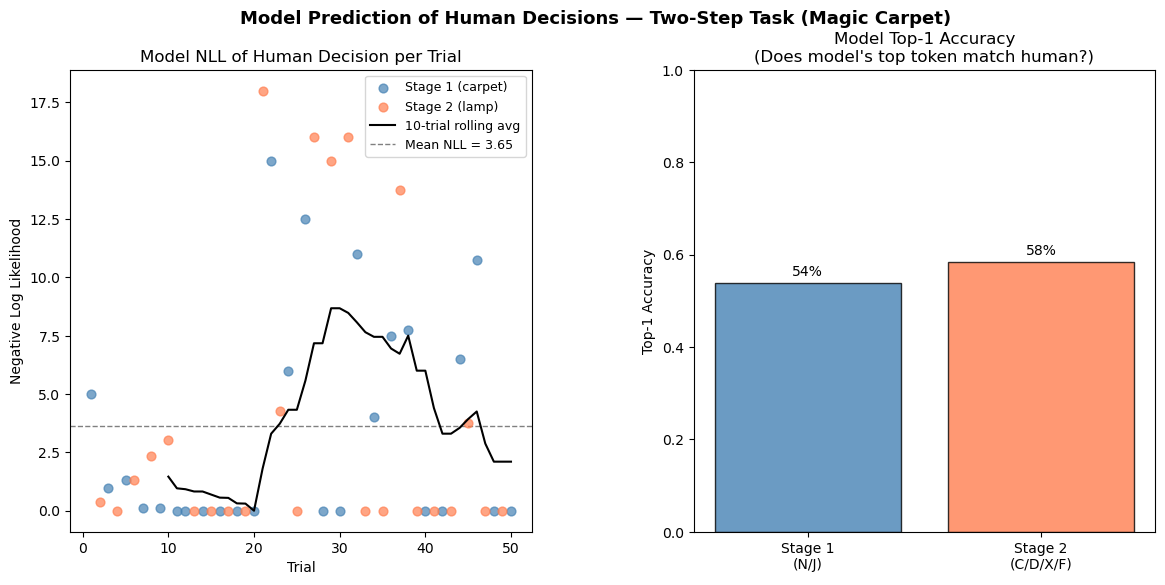

In [420]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(1, 2, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
window = 10
nll_array = np.array(nll, dtype=float)

ax1.scatter([trial_nums[i] for i in s1_idx], [nll[i] for i in s1_idx],
            color='steelblue', label='Stage 1 (carpet)', alpha=0.7, s=40, zorder=3)
ax1.scatter([trial_nums[i] for i in s2_idx], [nll[i] for i in s2_idx],
            color='coral', label='Stage 2 (lamp)', alpha=0.7, s=40, zorder=3)

rolling_nll = np.convolve(np.where(np.isnan(nll_array), 0, nll_array),
                           np.ones(window)/window, mode='valid')
ax1.plot(trial_nums[window-1:], rolling_nll, color='black',
         linewidth=1.5, label=f'{window}-trial rolling avg', zorder=4)
ax1.axhline(np.nanmean(nll_array), color='gray', linestyle='--', linewidth=1,
            label=f'Mean NLL = {np.nanmean(nll_array):.2f}')
ax1.set_xlabel('Trial')
ax1.set_ylabel('Negative Log Likelihood')
ax1.set_title('Model NLL of Human Decision per Trial')
ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs[1])
acc_s1 = np.mean([model_correct[i] for i in s1_idx])
acc_s2 = np.mean([model_correct[i] for i in s2_idx])
bars = ax2.bar(['Stage 1\n(N/J)', 'Stage 2\n(C/D/X/F)'],
               [acc_s1, acc_s2],
               color=['steelblue', 'coral'], alpha=0.8, edgecolor='black')
ax2.set_ylabel('Top-1 Accuracy')
ax2.set_title("Model Top-1 Accuracy\n(Does model's top token match human?)")
ax2.set_ylim(0, 1)
for bar, val in zip(bars, [acc_s1, acc_s2]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.0%}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Model Prediction of Human Decisions — Two-Step Task (Magic Carpet)',
             fontsize=13, fontweight='bold')
plt.savefig('two_step_nll.png', dpi=150, bbox_inches='tight')
plt.show()

### 2) Model Behavior in an Open Environment on the Two Step Task

Rather than tracking alignment with a human participant, here we let the model play the two step task autonomously. Instead of updating the context with a human's decisions and outcomes, we simulate the full environment, including the probabilistic transition structure and drifting reward probabilities, and update the context with the model's own choices and the resulting outcomes. There is no human in the loop. This allows us to characterize the model's evolving decision making behavior: does it explore or exploit? Does it adapt to changing reward probabilities? And most importantly, does its pattern of choices reflect model based or model free reasoning: the key behavioral signature the two-step task was designed to measure. Rather than measuring NLL, we now analyze the model's choice behavior directly, using the same stay/switch analysis based on whether or not a decision at the first choice stage led to a reward later on.

In [441]:

class TwoStepSimulator:
    def __init__(self):

        self.transitions = {
            'N': ('Pink', 0.7),  
            'J': ('Blue', 0.7),   
        }
        self.mountain_lamps = {
            'Pink': ['C', 'D'],
            'Blue': ['X', 'F'],
        }
        
        self.reward_probs = {
            'C': np.random.uniform(0.25, 0.75),
            'D': np.random.uniform(0.25, 0.75),
            'X': np.random.uniform(0.25, 0.75),
            'F': np.random.uniform(0.25, 0.75),
        }

    def step(self, carpet, lamp):
        
        common_mountain, common_prob = self.transitions[carpet]
        rare_mountain = 'Blue' if common_mountain == 'Pink' else 'Pink'
        mountain = common_mountain if np.random.random() < common_prob else rare_mountain
        transition_type = 'common' if mountain == common_mountain else 'rare'

        valid_lamps = self.mountain_lamps[mountain]

        reward = int(np.random.random() < self.reward_probs[lamp])

        for genie in self.reward_probs:
            self.reward_probs[genie] += np.random.normal(0, 0.025)
            self.reward_probs[genie] = np.clip(self.reward_probs[genie], 0.1, 0.9)

        return mountain, transition_type, reward, valid_lamps


def sample_from_logprobs(logprobs, valid_tokens):
    valid_entries = [e for e in logprobs if e.token.strip().upper() in valid_tokens]
    if not valid_entries:
        return np.random.choice(list(valid_tokens))
    tokens = [e.token.strip().upper() for e in valid_entries]
    log_p = np.array([e.logprob for e in valid_entries])
    
    p = np.exp(log_p)
    p = p / p.sum()
    return np.random.choice(tokens, p=p)


def format_trial(carpet, mountain, lamp, reward):
    return (f"\n\nYou are presented with magic carpets J and N. "
            f"You press <<{carpet}>>. "
            f"You end up on {mountain} Mountain. "
            f"You are presented with lamp {' and lamp '.join(simulator.mountain_lamps[mountain])}. "
            f"You rub lamp <<{lamp}>>. "
            f"You receive {reward} coins.")


simulator = TwoStepSimulator()
model_context = initial_prompt

n_trials = 30
STAGE1_VALID = {'N', 'J'}

results = []

for trial in tqdm(range(n_trials)):

    s1_prompt = model_context + "\n\nYou are presented with magic carpets J and N. You press <<"
    s1_response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": s1_prompt}],
        top_logprobs=5,
        logprobs=True,
        reasoning_effort=None
    )
    s1_logprobs = s1_response.choices[0].logprobs.content[0].top_logprobs
    carpet = sample_from_logprobs(s1_logprobs, STAGE1_VALID)

    common_mountain, common_prob = simulator.transitions[carpet]
    rare_mountain = 'Blue' if common_mountain == 'Pink' else 'Pink'
    mountain = common_mountain if np.random.random() < common_prob else rare_mountain
    transition_type = 'common' if mountain == common_mountain else 'rare'
    valid_lamps = simulator.mountain_lamps[mountain]

    s2_prefix = (f"\n\nYou are presented with magic carpets J and N. "
             f"You press <<{carpet}>>. "
             f"You end up on {mountain} Mountain. "
             f"You are presented with lamp {' and lamp '.join(valid_lamps)}. "
             f"You rub lamp <<")
    
    s2_prompt = model_context + s2_prefix
    s2_response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": s2_prompt}],
        top_logprobs=5,
        logprobs=True,
        reasoning_effort=None
    )
    s2_logprobs = s2_response.choices[0].logprobs.content[0].top_logprobs
    lamp = sample_from_logprobs(s2_logprobs, set(valid_lamps))

    reward = int(np.random.random() < simulator.reward_probs[lamp])

    for genie in simulator.reward_probs:
        simulator.reward_probs[genie] += np.random.normal(0, 0.025)
        simulator.reward_probs[genie] = np.clip(simulator.reward_probs[genie], 0.1, 0.9)

    model_context += format_trial(carpet, mountain, lamp, reward)

    results.append({
        'trial': trial + 1,
        'carpet': carpet,
        'mountain': mountain,
        'transition_type': transition_type,
        'lamp': lamp,
        'reward': reward,
        's1_logprobs': s1_logprobs,
        's2_logprobs': s2_logprobs,
    })

print(f"Total reward: {sum(r['reward'] for r in results)} / {n_trials} trials")
print(f"Reward rate: {np.mean([r['reward'] for r in results]):.2f}")

100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [03:45<00:00,  7.52s/it]

Total reward: 17 / 30 trials
Reward rate: 0.57


The above code implements a full simulation of the two step task environment. The `TwoStepSimulator` class maintains the task's probabilistic transition structure (carpet N usually lands on Pink Mountain, J on Blue, each with 70% probability) and a set of slowly drifting reward probabilities for each genie, updated via a Gaussian random walk after every trial. At each trial, the model is queried twice: once for the stage 1 carpet choice and once for the stage 2 lamp choice, with the full trial history provided as context each time. The model's choices are sampled proportionally from the log probabilities it assigns to valid tokens, rather than always taking the most probable option, which encourages more naturalistic exploratory behavior. The context is then updated with the model's actual choice and the reward received from the simulator, so each subsequent trial is conditioned on the model's own unfolding history in the task.

The below code produces three figures summarizing the model's behavior in the task. The top panel plots the reward received on each trial along with a 10 trial rolling average, giving a sense of whether the model improves at earning coins over time or settles into a stable reward rate.

The bottom left panel is a proxy for potentially revealing model free versus model based behavior. For each trial, we look at whether the model repeated its previous carpet choice (a "stay") or switched. We then split these stay/switch decisions by two factors: whether the previous trial was rewarded, and whether the transition was common or rare. A model free agent only cares about reward, it stays after reward and switches after no reward, regardless of transition type, producing parallel bars. A model based agent also accounts for the transition structure, understanding that a rare transition means the chosen carpet actually led somewhere unexpected, and adjusting accordingly. This produces an interaction between reward and transition type.

The bottom right panel simply shows how often the model chose each carpet and lamp across all trials, letting us check whether the model explored the full action space or became biased toward particular options.

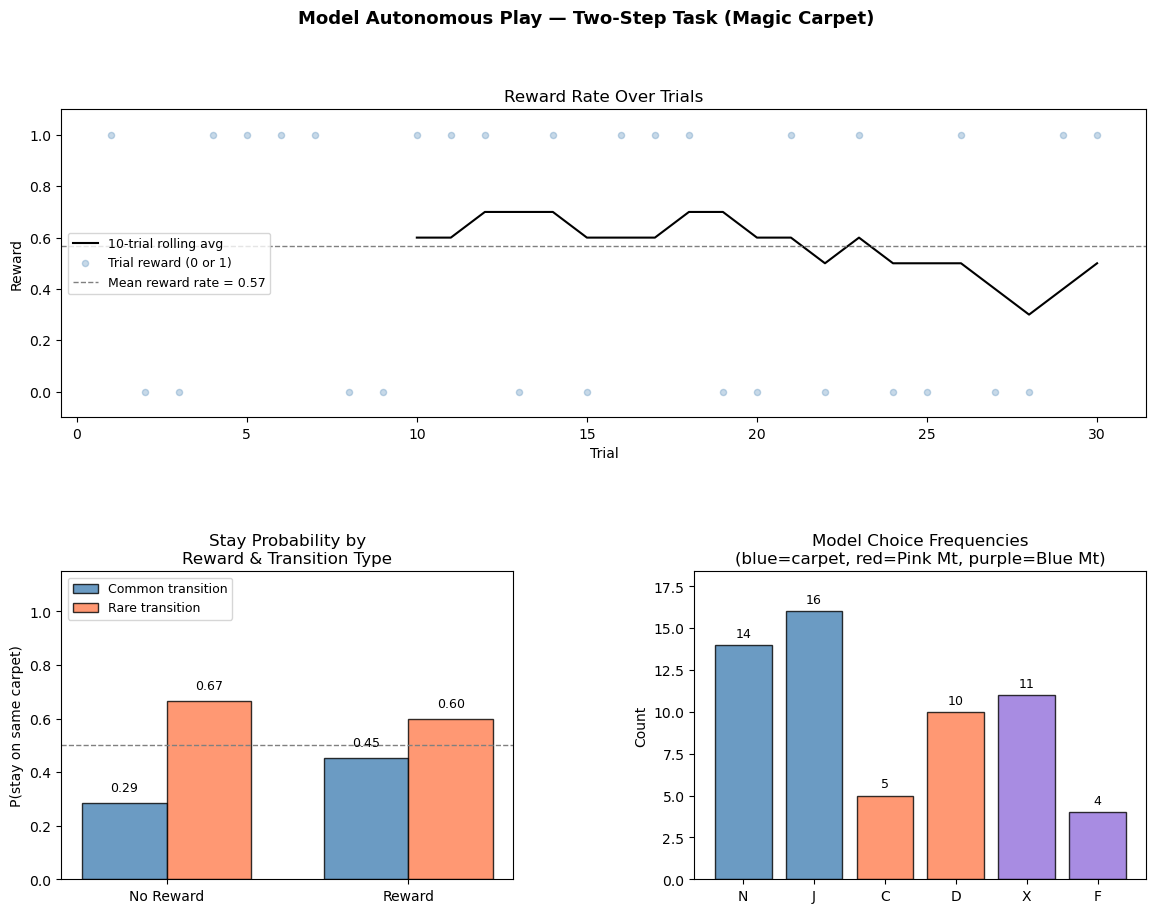

In [442]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, hspace=0.5, wspace=0.4)

rewards = [r['reward'] for r in results]
carpets = [r['carpet'] for r in results]
transitions = [r['transition_type'] for r in results]
lamps = [r['lamp'] for r in results]
trials = [r['trial'] for r in results]

window = 10
reward_array = np.array(rewards, dtype=float)
rolling_reward = np.convolve(reward_array, np.ones(window)/window, mode='valid')

stay = []
prev_rewarded = []
prev_transition = []

for i in range(1, len(results)):
    stay.append(carpets[i] == carpets[i-1])
    prev_rewarded.append(rewards[i-1])
    prev_transition.append(transitions[i-1])

stay = np.array(stay)
prev_rewarded = np.array(prev_rewarded)
prev_transition = np.array(prev_transition)

def stay_prob(rewarded, transition):
    mask = (prev_rewarded == rewarded) & (prev_transition == transition)
    return np.mean(stay[mask]) if mask.sum() > 0 else np.nan

sp_reward_common   = stay_prob(1, 'common')
sp_reward_rare     = stay_prob(1, 'rare')
sp_noreward_common = stay_prob(0, 'common')
sp_noreward_rare   = stay_prob(0, 'rare')

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(trials[window-1:], rolling_reward, color='black', linewidth=1.5, label=f'{window}-trial rolling avg')
ax1.scatter(trials, rewards, alpha=0.3, s=20, color='steelblue', label='Trial reward (0 or 1)', zorder=2)
ax1.axhline(np.mean(rewards), color='gray', linestyle='--', linewidth=1,
            label=f'Mean reward rate = {np.mean(rewards):.2f}')
ax1.set_xlabel('Trial')
ax1.set_ylabel('Reward')
ax1.set_title('Reward Rate Over Trials')
ax1.set_ylim(-0.1, 1.1)
ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs[1, 0])
x = np.array([0, 1])
width = 0.35
bars_common = [sp_noreward_common, sp_reward_common]
bars_rare   = [sp_noreward_rare,   sp_reward_rare]

ax2.bar(x - width/2, bars_common, width, label='Common transition', color='steelblue', alpha=0.8, edgecolor='black')
ax2.bar(x + width/2, bars_rare,   width, label='Rare transition',   color='coral',     alpha=0.8, edgecolor='black')
ax2.set_xticks(x)
ax2.set_xticklabels(['No Reward', 'Reward'])
ax2.set_ylabel('P(stay on same carpet)')
ax2.set_title('Stay Probability by\nReward & Transition Type')
ax2.set_ylim(0, 1.15)
ax2.legend(fontsize=9, loc='upper left')
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=1)

for xi, val in zip(x - width/2, bars_common):
    if not np.isnan(val):
        ax2.text(xi, val + 0.03, f'{val:.2f}', ha='center', va='bottom', fontsize=9)
for xi, val in zip(x + width/2, bars_rare):
    if not np.isnan(val):
        ax2.text(xi, val + 0.03, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

ax3 = fig.add_subplot(gs[1, 1])
all_choices = carpets + lamps
choice_labels = ['N', 'J', 'C', 'D', 'X', 'F']
choice_counts = [all_choices.count(c) for c in choice_labels]
colors = ['steelblue', 'steelblue', 'coral', 'coral', 'mediumpurple', 'mediumpurple']
bars3 = ax3.bar(choice_labels, choice_counts, color=colors, alpha=0.8, edgecolor='black')
ax3.set_ylabel('Count')
ax3.set_title('Model Choice Frequencies\n(blue=carpet, red=Pink Mt, purple=Blue Mt)')
ax3.set_ylim(0, max(choice_counts) * 1.15)
for bar, val in zip(bars3, choice_counts):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Autonomous Play — Two-Step Task (Magic Carpet)',
             fontsize=13, fontweight='bold')
plt.savefig('two_step_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

The model achieves a mean reward rate of 0.57, only slightly above chance. In the earlier set of trials the rolling average for the reward rate was above 60% but then later dips, suggesting the mdoel was not able to adapt to the drifting probabilities of rewards at different stages.

After unrewarded trials, the model switches more following common transitions (0.29) than rare ones (0.67). This is consistent with model based reasoning, since a rare transition implies the chosen carpet was not really "responsible" for landing somewhere unrewarding. A similar pattern holds after reward (0.45 vs 0.60). This interaction between reward and transition type is indicative of model based influences, suggesting the model may have some implicit understanding of the task's transition structure.

The choice frequency plot shows roughly balanced carpet selection (N=14, J=16) indicating exploration at stage 1, but the lamp choices are uneven: the model strongly prefers D and X over C and F, which may reflect early reward history biasing its behavior.

### References

[1] Binz, Marcel, et al. "A foundation model to predict and capture human cognition." Nature 644.8078 (2025): 1002-1009.

[2] Feher da Silva, Carolina, et al. "Rethinking model-based and model-free influences on mental effort and striatal prediction errors." Nature Human Behaviour 7.6 (2023): 956-969.